# Sketch to picture mapper

Amélio : tester avec FGSBIR au lieu de CLIP pour la discriminative loss- On a pris CLIP parce que c'est déja entrainé donc va plus vite.

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np

In [38]:
!pip install lpips

Defaulting to user installation because normal site-packages is not writeable


In [39]:
from datasets import ChairV2Dataset, PhotoOnlyDataset, PartialSketchAugmentation, TripletChairDataset
from modelfullreworked import SketchMapper, PhotoMapper, FGSBIRModel, EarlyStopping
from lossfullreworked import SketchMapperLoss, PhotoMapperLoss, TripletLoss

# PB sur le photo mapper avec 14 latents, et des pb sur les métadaonnées du modèles .pt qui nécessitent d'etre corrigées (=fout la merde ?)

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pickle
from tqdm import tqdm
import lpips

In [41]:
# ============================================================
# CHARGEMENT STYLEGAN (CORRIGÉ)
# ============================================================

def load_stylegan(checkpoint_path, stylegan_repo_path="/stylegan3"):
    """Charge le générateur StyleGAN3 pré-entraîné correctement"""
    
    import sys
    sys.path.append(stylegan_repo_path)
    
    import legacy
    
    print(f"📦 Chargement StyleGAN depuis {checkpoint_path}")
    
    with open(checkpoint_path, 'rb') as f:
        data = legacy.load_network_pkl(f)
    
    # Toujours utiliser G_ema
    G = data['G_ema'].cuda()
    
    # Freeze
    for param in G.parameters():
        param.requires_grad = False
    
    G.eval()
    
    print(f"   ✅ z_dim: {G.z_dim}")
    print(f"   ✅ w_dim: {G.w_dim}")
    print(f"   ✅ resolution: {G.img_resolution}")
    
    return G

In [42]:
# ============================================================
# DATALOADER FACTORY
# ============================================================

def create_dataloaders(
    root_dir='/Data/arthur.buis/pairs-sketch/ChairV2',
    resolution=128,
    batch_size=8,
    num_workers=4
):
    """
    Crée tous les dataloaders nécessaires
    
    Returns:
        dict avec:
        - 'photo_train': Pour entraîner Photo Mapper
        - 'photo_val': Pour valider Photo Mapper
        - 'pair_train': Pour entraîner Sketch Mapper
        - 'pair_val': Pour valider Sketch Mapper
    """
    
    print("="*60)
    print("📦 CRÉATION DATALOADERS")
    print("="*60)
    
    # Photo Mapper datasets
    print("\n🖼️  Photo-Only Datasets:")
    photo_train = PhotoOnlyDataset(
        root_dir=root_dir,
        split='train',
        resolution=resolution,
        augment=True
    )
    
    photo_val = PhotoOnlyDataset(
        root_dir=root_dir,
        split='test',
        resolution=resolution,
        augment=False
    )
    
    # Sketch-Photo pair datasets
    print("\n🎨 Sketch-Photo Pair Datasets:")
    pair_train = ChairV2Dataset(
        root_dir=root_dir,
        split='train',
        resolution=resolution,
        augment=True
    )
    
    pair_val = ChairV2Dataset(
        root_dir=root_dir,
        split='test',
        resolution=resolution,
        augment=False
    )
    
    # DataLoaders
    dataloaders = {
        'photo_train': DataLoader(
            photo_train,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
            drop_last=True
        ),
        
        'photo_val': DataLoader(
            photo_val,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True
        ),
        
        'pair_train': DataLoader(
            pair_train,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
            drop_last=True
        ),
        
        'pair_val': DataLoader(
            pair_val,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True
        ),
    }
    
    print("\n" + "="*60)
    print("✅ DataLoaders créés:")
    for name, loader in dataloaders.items():
        print(f"   {name:15} {len(loader):5} batches")
    print("="*60)
    
    return dataloaders

In [43]:
# ============================================================
# TRAINING LOOP
# ============================================================
from pathlib import Path

def train_photo_mapper(
    dataset_root,  # ← Changé: root du dataset ChairV2
    stylegan_checkpoint,
    output_dir='./checkpoints_photo_mapper',
    num_epochs=50,
    batch_size=8,
    lr=1e-5,
    resolution=128,
    num_workers=4,
    save_frequency=10,
    validate_frequency=5
):
    """
    Entraîne le Photo Mapper (Teacher Er)
    
    Args:
        dataset_root: Chemin vers ChairV2/ (contient trainB/, testB/)
        stylegan_checkpoint: Checkpoint StyleGAN pré-entraîné
        num_epochs: Nombre d'epochs
        batch_size: Taille des batches
        lr: Learning rate
        resolution: Résolution des images (128 ou 256)
        num_workers: Nombre de workers DataLoader
        save_frequency: Sauvegarder tous les N epochs
        validate_frequency: Valider tous les N epochs
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print("="*60)
    print("🎓 PHASE 1: ENTRAÎNEMENT PHOTO MAPPER (TEACHER)")
    print("="*60)

    # =====================================
    # 1. Charger StyleGAN
    # =====================================

    G = load_stylegan(stylegan_checkpoint)
    num_ws = getattr(G.synthesis, 'num_ws', getattr(G, 'num_ws', None))
    if num_ws is None:
        raise RuntimeError('Impossible de déterminer num_ws depuis StyleGAN')
    print(f"   ✅ num_ws: {num_ws}")

    # =====================================
    # 2. Créer Photo Mapper
    # =====================================

    print("\n📦 Création Photo Mapper...")

    photo_mapper = PhotoMapper(
        latent_dim=G.w_dim,
        num_latents=num_ws,
        feature_dim=2048,
        hidden_dim=256
    ).cuda()

    params = sum(p.numel() for p in photo_mapper.parameters() if p.requires_grad)
    print(f"   Paramètres entraînables: {params:,}")

    # =====================================
    # 3. Dataset & DataLoader
    # =====================================

    print("\n📊 Chargement datasets...")

    train_dataset = PhotoOnlyDataset(
        root_dir=dataset_root,
        split='train',
        resolution=resolution,
        augment=True
    )

    val_dataset = PhotoOnlyDataset(
        root_dir=dataset_root,
        split='test',
        resolution=resolution,
        augment=False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    print(f"   Train: {len(train_dataset)} photos → {len(train_loader)} batches")
    print(f"   Val:   {len(val_dataset)} photos → {len(val_loader)} batches")

    # =====================================
    # 4. Loss & Optimizer
    # =====================================

    criterion = PhotoMapperLoss()

    optimizer = optim.Adam(
        photo_mapper.parameters(),
        lr=lr,
        betas=(0.9, 0.999),
        weight_decay=1e-5
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
    )

    # Mixed Precision Scaler
    scaler = torch.cuda.amp.GradScaler()

    def align_ws(ws):
        # Aligne la dimension num_ws au générateur pour éviter les AssertionError.
        if ws.ndim == 2:
            ws = ws.unsqueeze(1)

        if ws.shape[1] > num_ws:
            ws = ws[:, :num_ws, :]
        elif ws.shape[1] < num_ws:
            pad = ws[:, -1:, :].repeat(1, num_ws - ws.shape[1], 1)
            ws = torch.cat([ws, pad], dim=1)
        return ws.contiguous()

    # =====================================
    # 5. History & tracking
    # =====================================

    history = {
        'train_loss': [], 'train_rec': [], 'train_lpips': [],
        'val_loss':   [], 'val_rec':   [], 'val_lpips':   [],
    }
    best_val_loss = float('inf')

    # =====================================
    # 6. Training Loop
    # =====================================

    print("\n🚀 Démarrage entraînement...\n")

    for epoch in range(1, num_epochs + 1):

        # ── TRAIN ──
        photo_mapper.train()
        train_losses, train_recs, train_lpips_vals = [], [], []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
        for batch in pbar:
            photos = batch['photo'].cuda()

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                w_plus = align_ws(photo_mapper(photos))
            with torch.cuda.amp.autocast(enabled=False):
                photo_gen = G.synthesis(w_plus.float(), noise_mode='const').clamp(-1, 1)
                loss, loss_dict = criterion(photos, photo_gen)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(photo_mapper.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_losses.append(loss.item())
            train_recs.append(loss_dict['rec'])
            train_lpips_vals.append(loss_dict['lpips'])

            pbar.set_postfix({
                'loss':  f"{loss.item():.4f}",
                'rec':   f"{loss_dict['rec']:.4f}",
                'lpips': f"{loss_dict['lpips']:.4f}",
            })

        avg_train_loss  = np.mean(train_losses)
        avg_train_rec   = np.mean(train_recs)
        avg_train_lpips = np.mean(train_lpips_vals)

        history['train_loss'].append(avg_train_loss)
        history['train_rec'].append(avg_train_rec)
        history['train_lpips'].append(avg_train_lpips)

        print(f"\n📊 Epoch {epoch}/{num_epochs} - Train:")
        print(f"   Loss: {avg_train_loss:.4f}  |  Rec: {avg_train_rec:.4f}  |  LPIPS: {avg_train_lpips:.4f}")

        # ── VALIDATION ──
        if epoch % validate_frequency == 0:
            photo_mapper.eval()
            val_losses, val_recs, val_lpips_vals = [], [], []

            with torch.no_grad():
                for batch in tqdm(val_loader, desc="Val"):
                    photos = batch['photo'].cuda()
                    with torch.cuda.amp.autocast():
                        w_plus = align_ws(photo_mapper(photos))
                    with torch.cuda.amp.autocast(enabled=False):
                        photo_gen = G.synthesis(w_plus.float(), noise_mode='const').clamp(-1, 1)
                        loss, loss_dict = criterion(photos, photo_gen)
                    val_losses.append(loss.item())
                    val_recs.append(loss_dict['rec'])
                    val_lpips_vals.append(loss_dict['lpips'])

            avg_val_loss  = np.mean(val_losses)
            avg_val_rec   = np.mean(val_recs)
            avg_val_lpips = np.mean(val_lpips_vals)

            history['val_loss'].append(avg_val_loss)
            history['val_rec'].append(avg_val_rec)
            history['val_lpips'].append(avg_val_lpips)

            print(f"📊 Epoch {epoch}/{num_epochs} - Val:")
            print(f"   Loss: {avg_val_loss:.4f}  |  Rec: {avg_val_rec:.4f}  |  LPIPS: {avg_val_lpips:.4f}")

            scheduler.step(avg_val_loss)

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': photo_mapper.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': avg_val_loss,
                    'config': {
                        'latent_dim': G.w_dim,
                        'num_latents': num_ws,
                        'feature_dim': 2048,
                        'hidden_dim': 256,
                        'resolution': resolution,
                    }
                }, output_dir / 'photo_mapper_best.pt')
                print(f"   💾 Meilleur modèle sauvegardé (val_loss={best_val_loss:.4f})")

        # ── CHECKPOINT PÉRIODIQUE ──
        if epoch % save_frequency == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': photo_mapper.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'history': history,
                'config': {
                    'latent_dim': G.w_dim,
                    'num_latents': num_ws,
                    'feature_dim': 2048,
                    'hidden_dim': 256,
                    'resolution': resolution,
                }
            }, output_dir / f'photo_mapper_{epoch:05d}.pt')
            print(f"   💾 Checkpoint: photo_mapper_{epoch:05d}.pt")

    # ── FINAL SAVE ──
    final_checkpoint = {
        'epoch': num_epochs,
        'model_state_dict': photo_mapper.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'config': {
            'latent_dim': G.w_dim,
            'num_latents': num_ws,
            'feature_dim': 2048,
            'hidden_dim': 256,
            'resolution': resolution,
        }
    }
    final_path = output_dir / f'photo_mapper_{num_epochs * len(train_loader):05d}.pt'
    torch.save(final_checkpoint, final_path)

    import json
    history_path = output_dir / 'training_history.json'
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    print("\n" + "="*60)
    print("✅ PHOTO MAPPER ENTRAÎNÉ")
    print(f"   Meilleur val loss: {best_val_loss:.4f}")
    print(f"   History sauvegardée: {history_path}")
    print("="*60)

    return photo_mapper, history


In [44]:
# ============================================================
# VISUALISATION RÉSULTATS
# ============================================================

def visualize_training_history(history_path, output_path='training_curves.png'):
    """Visualise les courbes d'entraînement"""
    
    import json
    import matplotlib.pyplot as plt
    
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    # if history['val_loss']:
    #     val_epochs = range(1, len(history['train_loss']) + 1, 
    #                       len(history['train_loss']) // len(history['val_loss']))
    #     axes[0].plot(val_epochs, history['val_loss'], 'r-', label='Val')
    
    # Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')

    if history['val_loss']:
        # Epochs réels où la validation a été faite
        val_epochs = np.linspace(
            1,
            len(history['train_loss']),
            num=len(history['val_loss'])
        )

        # Interpolation sur tous les epochs
        val_interp = np.interp(
            epochs,          # où on veut les valeurs
            val_epochs,      # x connus
            history['val_loss']  # y connus
        )

        axes[0].plot(epochs, val_interp, 'r--', label='Val (interp)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Total Loss')
    axes[0].set_title('Total Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Reconstruction Loss
    axes[1].plot(epochs, history['train_rec'], 'b-', label='Train')
    if history['val_rec']:
        axes[1].plot(val_epochs, history['val_rec'], 'r-', label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('L2 Reconstruction Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # LPIPS Loss
    axes[2].plot(epochs, history['train_lpips'], 'b-', label='Train')
    if history['val_lpips']:
        axes[2].plot(val_epochs, history['val_lpips'], 'r-', label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LPIPS Loss')
    axes[2].set_title('Perceptual Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Courbes sauvegardées: {output_path}")


In [45]:
#import de legacy et dnnlib depuis le repo stylegan3 (pour éviter conflits avec d'autres versions)

import sys
repo_path = "/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3"
sys.path.insert(0, repo_path)
for m in ["legacy", "dnnlib", "torch_utils"]:
    if m in sys.modules:
        del sys.modules[m]
import dnnlib
import legacy
import torch

print("✅ legacy chargé depuis:", legacy.__file__) #Doit renvoyer le repo stylegan3
print("✅ dnnlib chargé depuis:", dnnlib.__file__)

✅ legacy chargé depuis: /users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3/legacy.py
✅ dnnlib chargé depuis: /users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3/dnnlib/__init__.py


In [46]:
# # Chemins
# dataset_root = '/Data/arthur.buis/pairs-sketch/ChairV2'
# stylegan_checkpoint = '/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3_training_chairs/network-snapshot-006400.pkl'

# # Entraîner
# photo_mapper, history = train_photo_mapper(
#     dataset_root=dataset_root,
#     stylegan_checkpoint=stylegan_checkpoint,
#     output_dir='/Data/arthur.buis/checkpoints_photo_mapper',
#     num_epochs=300, #300 à 400 suffit amplement !
#     batch_size=8,
#     lr=1e-5,
#     resolution=128,
#     num_workers=4,
#     save_frequency=10,
#     validate_frequency=1
# )

In [47]:
# # ============================================================
# # CORRIGER LE CHECKPOINT PHOTO MAPPER
# # ============================================================

# import torch
# from pathlib import Path

# photo_mapper_checkpoint = '/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt'
# corrected_checkpoint = '/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000_CORRECTED.pt'

# print("🔧 CORRECTION DU CHECKPOINT")
# print("="*60)

# # Charger
# checkpoint = torch.load(photo_mapper_checkpoint, map_location='cpu')

# print(f"\n❌ Ancienne config:")
# for k, v in checkpoint['config'].items():
#     print(f"   {k}: {v}")

# # Analyser state_dict
# state_dict = checkpoint['model_state_dict']

# fc_init_weight = state_dict['fc_init.0.weight']
# hidden_dim = fc_init_weight.shape[0]
# feature_dim = fc_init_weight.shape[1]

# fc_out_weight = state_dict['fc_out.weight']
# latent_dim = fc_out_weight.shape[0]

# print(f"\n🔍 Dimensions détectées:")
# print(f"   feature_dim: {feature_dim}")
# print(f"   hidden_dim: {hidden_dim}")
# print(f"   latent_dim: {latent_dim}")

# # ✅ CORRIGER LA CONFIG
# checkpoint['config'] = {
#     'latent_dim': latent_dim,
#     'num_latents': 12,  # ← CORRIGÉ! (était 14)
#     'feature_dim': feature_dim,
#     'hidden_dim': hidden_dim,
#     'resolution': 128
# }

# print(f"\n✅ Nouvelle config:")
# for k, v in checkpoint['config'].items():
#     print(f"   {k}: {v}")

# # Sauvegarder
# torch.save(checkpoint, corrected_checkpoint)

# size_mb = Path(corrected_checkpoint).stat().st_size / (1024**2)
# print(f"\n✅ Checkpoint corrigé sauvegardé:")
# print(f"   Chemin: {corrected_checkpoint}")
# print(f"   Taille: {size_mb:.1f} MB")

# # Tester
# print(f"\n🧪 Test de chargement...")
# test = torch.load(corrected_checkpoint, map_location='cpu')

# print(f"   Config: {test['config']}")
# print(f"   ✅ Checkpoint valide!")

# print(f"\n💡 UTILISEZ CE NOUVEAU CHECKPOINT:")
# print(f"   photo_mapper_checkpoint = '{corrected_checkpoint}'")

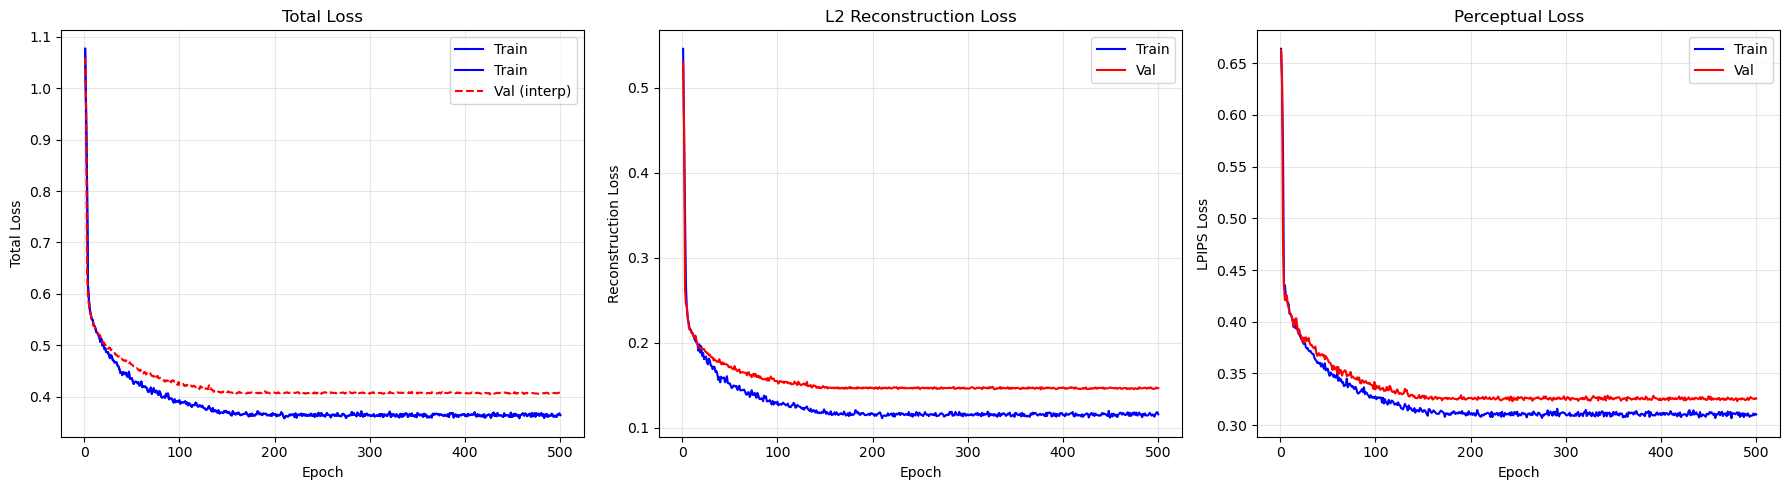

✅ Courbes sauvegardées: /Data/arthur.buis/checkpoints_photo_mapper/training_curves.png


In [48]:
# Visualiser courbes
visualize_training_history(
    '/Data/arthur.buis/checkpoints_photo_mapper/training_history.json',
    '/Data/arthur.buis/checkpoints_photo_mapper/training_curves.png'
)

In [49]:
from pathlib import Path
import pickle
import torch

def safe_torch_load(path, map_location='cpu', trusted_source=True):
    """
    PyTorch >= 2.6: weights_only=True par défaut.
    On tente d'abord le mode sûr, puis fallback explicite si la source est fiable.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except pickle.UnpicklingError as e:
        print(f"⚠️ Chargement sûr échoué: {e}")
        if not trusted_source:
            raise
        print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
        return torch.load(path, map_location=map_location, weights_only=False)

# Vérifier que le fichier existe
model_path = Path('/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt')

if model_path.exists():
    size_mb = model_path.stat().st_size / 1e6
    print(f"✅ Fichier trouvé ! ({size_mb:.1f} MB)")
    
    # Inspecter le contenu du checkpoint
    ckpt = safe_torch_load(model_path, map_location='cpu', trusted_source=True)
    print("Clés disponibles :", list(ckpt.keys()))
    print("Config :", ckpt.get('config', 'non trouvée'))
else:
    print("❌ Fichier non trouvé à ce chemin")
    # Essayer avec slash au début
    alt = Path('/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt')
    print(f"Chemin alternatif /Data/... existe : {alt.exists()}")

✅ Fichier trouvé ! (319.8 MB)
⚠️ Chargement sûr échoué: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documenta

In [50]:
# ============================================================
# TESTER LE CHARGEMENT D'UN CHECKPOINT
# ============================================================

from pathlib import Path
import pickle
import torch

def safe_torch_load(path, map_location='cpu', trusted_source=True):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except pickle.UnpicklingError as e:
        print(f"⚠️ Chargement sûr échoué: {e}")
        if not trusted_source:
            raise
        print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
        return torch.load(path, map_location=map_location, weights_only=False)

# REMPLACEZ CE CHEMIN par celui trouvé ci-dessus
checkpoint_path = '/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt'  # ← MODIFIER

checkpoint_path = Path(checkpoint_path)

print(f"🧪 TEST DE CHARGEMENT")
print(f"   Fichier: {checkpoint_path.name}")
print(f"   Chemin: {checkpoint_path}")

if checkpoint_path.exists():
    print(f"   ✅ Fichier existe")
    print(f"   Taille: {checkpoint_path.stat().st_size / (1024**2):.1f} MB")
    
    try:
        # Charger le checkpoint
        print("\n📦 Chargement...")
        checkpoint = safe_torch_load(checkpoint_path, map_location='cpu', trusted_source=True)
        
        print(f"✅ CHARGEMENT RÉUSSI!")
        print(f"\n📋 Contenu du checkpoint:")
        print(f"   Clés: {list(checkpoint.keys())}")
        
        # Afficher détails
        if 'epoch' in checkpoint:
            print(f"\n   Epoch: {checkpoint['epoch']}")
        
        if 'val_loss' in checkpoint:
            print(f"   Val Loss: {checkpoint['val_loss']:.4f}")
        
        if 'train_loss' in checkpoint:
            print(f"   Train Loss: {checkpoint['train_loss']:.4f}")
        
        if 'config' in checkpoint:
            print(f"\n   Configuration:")
            for key, val in checkpoint['config'].items():
                print(f"      {key}: {val}")
        
        if 'history' in checkpoint:
            hist = checkpoint['history']
            if 'train_loss' in hist:
                n_epochs = len(hist['train_loss'])
                print(f"\n   Historique: {n_epochs} epochs")
                if n_epochs > 0:
                    print(f"      Premier train loss: {hist['train_loss'][0]:.4f}")
                    print(f"      Dernier train loss: {hist['train_loss'][-1]:.4f}")
        
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
            print(f"\n   État du modèle:")
            print(f"      {len(state_dict)} paramètres")
            print(f"      Première clé: {list(state_dict.keys())[0]}")
        
        print("\n✅ CE FICHIER EST VALIDE!")
        
    except Exception as e:
        print(f"\n❌ ERREUR DE CHARGEMENT: {e}")
        print(f"   Le fichier est peut-être corrompu")

else:
    print(f"   ❌ Fichier introuvable")
    print(f"\n💡 Chemins testés:")
    print(f"      {checkpoint_path}")
    print(f"      {checkpoint_path.absolute()}")

🧪 TEST DE CHARGEMENT
   Fichier: photo_mapper_32000.pt
   Chemin: /Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt
   ✅ Fichier existe
   Taille: 305.0 MB

📦 Chargement...
⚠️ Chargement sûr échoué: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `tor

In [51]:
import pickle
import torch

def safe_torch_load(path, map_location='cpu', trusted_source=True):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except pickle.UnpicklingError as e:
        print(f"⚠️ Chargement sûr échoué: {e}")
        if not trusted_source:
            raise
        print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
        return torch.load(path, map_location=map_location, weights_only=False)

def load_photo_mapper(checkpoint_path, model_class, device="cuda", trusted_source=True):
    """
    Charge un PhotoMapper depuis un checkpoint.

    Args:
        checkpoint_path: chemin vers .pt
        model_class: classe PhotoMapper utilisée pendant l'entraînement
        device: cuda ou cpu
        trusted_source: True si le checkpoint est de confiance (autorise fallback unsafe)

    Returns:
        photo_mapper chargé
        config du modèle
    """

    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=device,
        trusted_source=trusted_source,
    )

    config = checkpoint["config"]

    print("📦 Chargement PhotoMapper")
    print("="*50)
    for k,v in config.items():
        print(f"{k}: {v}")

    # reconstruire le modèle
    model = model_class(
        latent_dim=config["latent_dim"],
        num_latents=config["num_latents"],
        feature_dim=config["feature_dim"],
        hidden_dim=config["hidden_dim"]
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    print("\n✅ PhotoMapper chargé avec succès")

    return model, config

In [52]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image
import random
from pathlib import Path

def visualize_photo_mapper(
    photo_mapper,
    stylegan_G,
    dataset_root,
    device="cuda",
    resolution=128,
    num_samples=5
):

    photo_mapper.eval()
    stylegan_G.eval()

    transform = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    dataset_root = Path(dataset_root)

    # chercher images récursivement
    images = list(dataset_root.rglob("*.png")) + list(dataset_root.rglob("*.jpg"))

    print(f"📂 Images trouvées: {len(images)}")

    if len(images) == 0:
        raise RuntimeError("❌ Aucune image trouvée dans le dataset")

    num_samples = min(num_samples, len(images))
    samples = random.sample(images, num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 3*num_samples))

    for i, img_path in enumerate(samples):

        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():

            latents = photo_mapper(img_tensor)

            generated = stylegan_G.synthesis(latents)

        generated = generated.clamp(-1,1)

        generated = (generated[0].permute(1,2,0).cpu().numpy()+1)/2
        original = (img_tensor[0].permute(1,2,0).cpu().numpy()+1)/2

        axes[i,0].imshow(original)
        axes[i,0].set_title("Photo")
        axes[i,0].axis("off")

        axes[i,1].imshow(generated)
        axes[i,1].set_title("Reconstruction")
        axes[i,1].axis("off")

    plt.tight_layout()
    plt.show()
    transform = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    # récupérer toutes les photos
    photo_dir = Path(dataset_root) / "photo"
    images = list(photo_dir.glob("*.png")) + list(photo_dir.glob("*.jpg"))

    samples = random.sample(images, num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 3*num_samples))

    for i, img_path in enumerate(samples):

        # charger image
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():

            # prédire latents
            latents = photo_mapper(img_tensor)

            # générer image
            generated = stylegan_G.synthesis(latents)

        generated = generated.clamp(-1,1)

        # tensor -> image
        generated = (generated[0].permute(1,2,0).cpu().numpy() + 1)/2
        original = (img_tensor[0].permute(1,2,0).cpu().numpy() + 1)/2

        axes[i,0].imshow(original)
        axes[i,0].set_title("Photo originale")
        axes[i,0].axis("off")

        axes[i,1].imshow(generated)
        axes[i,1].set_title("Reconstruction StyleGAN")
        axes[i,1].axis("off")

    plt.tight_layout()
    plt.show()

In [53]:
stylegan_repo_path = "/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3"
stylegan_checkpoint = "/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3_training_chairs/network-snapshot-006400.pkl"
G = load_stylegan(stylegan_checkpoint, stylegan_repo_path=stylegan_repo_path)
photo_mapper_checkpoint = "/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt"
photo_mapper, config = load_photo_mapper(
    checkpoint_path=photo_mapper_checkpoint,
    model_class=PhotoMapper,
    device="cuda"
 )

# visualize_photo_mapper(
#     photo_mapper=photo_mapper,
#     stylegan_G=G,
#     dataset_root="/Data/arthur.buis/pairs-sketch/ShoV2",
#     device="cuda",
#     resolution=128,
#     num_samples=4
# )

📦 Chargement StyleGAN depuis /users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3_training_chairs/network-snapshot-006400.pkl
   ✅ z_dim: 256
   ✅ w_dim: 256
   ✅ resolution: 128
⚠️ Chargement sûr échoué: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.cor

/users/eleves-b/2023/arthur.buis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/eleves-b/2023/arthur.buis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✅ PhotoMapper chargé avec succès


# ENtrainement FGSBIR

In [54]:
# ============================================================
# FG-SBIR MODEL - VERSION COMPLÈTE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm
import numpy as np
from pathlib import Path
import random

In [55]:
# # ============================================================
# # TESTER TRIPLET DATASET
# # ============================================================

# print("🧪 Test du TripletChairDataset...\n")

# # Créer dataset
# test_dataset = TripletChairDataset(
#     root_dir='/Data/arthur.buis/pairs-sketch/ChairV2',
#     split='train',
#     resolution=128
# )

# # Tester un sample
# sample = test_dataset[0]

# print(f"\n✅ Sample test:")
# print(f"   anchor_sketch shape: {sample['anchor_sketch'].shape}")
# print(f"   positive_photo shape: {sample['positive_photo'].shape}")
# print(f"   negative_photo shape: {sample['negative_photo'].shape}")

# # Vérifier que positive et negative sont différents
# print(f"\n🔍 Vérification:")
# print(f"   Anchor et Positive sont appairés: ✅")
# print(f"   Negative est différent: {'✅' if not torch.equal(sample['positive_photo'], sample['negative_photo']) else '❌'}")

# # Stats
# print(f"\n📊 Statistiques dataset:")
# print(f"   Total triplets: {len(test_dataset)}")
# print(f"   Photos uniques: {len(test_dataset.all_photo_ids)}")

In [56]:
# =====================================
# 4. TRAINING LOOP
# =====================================

from pathlib import Path
import sys

# Assure l'import du module local datasets.py depuis le dossier Project
project_dir = Path.cwd()
if (project_dir / 'datasets.py').exists() and str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from datasets import TripletChairDataset


def train_fgsbir(
    dataset_root,
    output_dir='/Data/arthur.buis/checkpoints_fgsbir',
    num_epochs=50,
    batch_size=8,
    lr=1e-4,
    resolution=128,
    num_workers=2,
    margin=0.2,
    save_frequency=10,
    amp=True,
    grad_accum_steps=1,
    device='auto'
):
    """
    Entraîne le modèle FG-SBIR.

    Astuces mémoire:
    - AMP (mixed precision)
    - accumulation de gradients
    - fallback OOM: skip batch + empty_cache
    - device='auto': bascule CPU si GPU saturé
    """
    
    # Sélection robuste du device
    if device == 'auto':
        if torch.cuda.is_available():
            free_mem, total_mem = torch.cuda.mem_get_info()
            free_gb = free_mem / (1024**3)
            if free_gb >= 4.0:
                device = 'cuda'
            else:
                device = 'cpu'
                print(f"⚠️ GPU saturé ({free_gb:.2f} GiB libres). Bascule automatique sur CPU.")
        else:
            device = 'cpu'
    
    use_cuda = (device == 'cuda' and torch.cuda.is_available())
    print(f"🖥️ Device utilisé: {device}")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print("="*60)
    print("🎯 ENTRAÎNEMENT FG-SBIR MODEL")
    print("="*60)
    
    # Modèle
    print("\n📦 Création FG-SBIR...")
    model = FGSBIRModel(embedding_dim=512).to(device)
    
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Paramètres: {params:,}")
    
    # Dataset
    print("\n📊 Chargement datasets...")
    train_dataset = TripletChairDataset(dataset_root, 'train', resolution)
    val_dataset = TripletChairDataset(dataset_root, 'test', resolution)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=use_cuda,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=use_cuda
    )
    
    print(f"   Train: {len(train_loader)} batches")
    print(f"   Val:   {len(val_loader)} batches")
    print(f"   AMP:   {amp and use_cuda}")
    print(f"   Grad accumulation: {grad_accum_steps}")
    
    # Loss & Optimizer
    criterion = TripletLoss(margin=margin)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(amp and use_cuda))
    
    if use_cuda:
        torch.cuda.empty_cache()
    
    # Training
    print("\n🚀 Démarrage entraînement...\n")
    
    best_val_loss = float('inf')
    history = {'train_loss': [], 'train_dist_pos': [], 'train_dist_neg': [],
               'val_loss': [], 'val_dist_pos': [], 'val_dist_neg': []}
    
    for epoch in range(num_epochs):
        
        # TRAINING
        model.train()
        optimizer.zero_grad(set_to_none=True)
        train_losses = []
        train_dist_pos = []
        train_dist_neg = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        
        for step, batch in enumerate(pbar, start=1):
            try:
                anchor_sketch = batch['anchor_sketch'].to(device, non_blocking=use_cuda)
                positive_photo = batch['positive_photo'].to(device, non_blocking=use_cuda)
                negative_photo = batch['negative_photo'].to(device, non_blocking=use_cuda)
                
                with torch.cuda.amp.autocast(enabled=(amp and use_cuda)):
                    anchor_emb = model.forward_sketch(anchor_sketch)
                    positive_emb = model.forward_photo(positive_photo)
                    negative_emb = model.forward_photo(negative_photo)
                    loss, loss_dict = criterion(anchor_emb, positive_emb, negative_emb)
                    loss = loss / max(1, grad_accum_steps)
                
                scaler.scale(loss).backward()
                
                if step % max(1, grad_accum_steps) == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                
                train_losses.append(loss.item() * max(1, grad_accum_steps))
                train_dist_pos.append(loss_dict['dist_pos'])
                train_dist_neg.append(loss_dict['dist_neg'])
                
                pbar.set_postfix({
                    'loss': f"{train_losses[-1]:.4f}",
                    'd+': f"{loss_dict['dist_pos']:.3f}",
                    'd-': f"{loss_dict['dist_neg']:.3f}"
                })
            except RuntimeError as e:
                if 'out of memory' in str(e).lower() and use_cuda:
                    print("⚠️ OOM sur un batch: batch ignoré + vidage cache CUDA")
                    optimizer.zero_grad(set_to_none=True)
                    torch.cuda.empty_cache()
                    continue
                raise
        
        # Si accumulation incomplète en fin d'epoch
        if len(train_loader) % max(1, grad_accum_steps) != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        
        avg_train_loss = np.mean(train_losses) if train_losses else float('nan')
        history['train_loss'].append(avg_train_loss)
        history['train_dist_pos'].append(np.mean(train_dist_pos) if train_dist_pos else float('nan'))
        history['train_dist_neg'].append(np.mean(train_dist_neg) if train_dist_neg else float('nan'))
        
        print(f"\n📊 Epoch {epoch+1} - Train:")
        print(f"   Loss: {avg_train_loss:.4f}")
        print(f"   Dist pos: {history['train_dist_pos'][-1]:.3f}")
        print(f"   Dist neg: {history['train_dist_neg'][-1]:.3f}")
        
        # VALIDATION
        model.eval()
        val_losses = []
        val_dist_pos = []
        val_dist_neg = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Val"):
                anchor_sketch = batch['anchor_sketch'].to(device, non_blocking=use_cuda)
                positive_photo = batch['positive_photo'].to(device, non_blocking=use_cuda)
                negative_photo = batch['negative_photo'].to(device, non_blocking=use_cuda)
                
                with torch.cuda.amp.autocast(enabled=(amp and use_cuda)):
                    anchor_emb = model.forward_sketch(anchor_sketch)
                    positive_emb = model.forward_photo(positive_photo)
                    negative_emb = model.forward_photo(negative_photo)
                    loss, loss_dict = criterion(anchor_emb, positive_emb, negative_emb)
                
                val_losses.append(loss.item())
                val_dist_pos.append(loss_dict['dist_pos'])
                val_dist_neg.append(loss_dict['dist_neg'])
        
        avg_val_loss = np.mean(val_losses) if val_losses else float('nan')
        history['val_loss'].append(avg_val_loss)
        history['val_dist_pos'].append(np.mean(val_dist_pos) if val_dist_pos else float('nan'))
        history['val_dist_neg'].append(np.mean(val_dist_neg) if val_dist_neg else float('nan'))
        
        print(f"\n📊 Epoch {epoch+1} - Val:")
        print(f"   Loss: {avg_val_loss:.4f}")
        print(f"   Dist pos: {history['val_dist_pos'][-1]:.3f}")
        print(f"   Dist neg: {history['val_dist_neg'][-1]:.3f}")
        
        scheduler.step(avg_val_loss)
        
        # Save best
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            
            try:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_loss': avg_val_loss,
                    'history': history,
                    'config': {'embedding_dim': 512}
                }, output_dir / 'fgsbir_best.pt')
                
                print(f"   ✅ Meilleur modèle sauvegardé")
            except Exception as e:
                print(f"   ⚠️  Erreur sauvegarde: {e}")
        
        # Save periodic
        if (epoch + 1) % save_frequency == 0:
            try:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                }, output_dir / f'fgsbir_epoch_{epoch+1:03d}.pt')
            except:
                pass
        
        print()
    
    print("\n" + "="*60)
    print("✅ FG-SBIR ENTRAÎNÉ")
    print(f"   Meilleur val loss: {best_val_loss:.4f}")
    print("="*60)
    
    return model, history

print("✅ train_fgsbir défini")

✅ train_fgsbir défini


In [57]:
# # ============================================================
# # PHASE 2 : ENTRAÎNER FG-SBIR
# # ============================================================

# import os
# import torch

# # Réduit la fragmentation mémoire CUDA
# os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# # Entraîner
# fgsbir_model, history = train_fgsbir(
#     dataset_root='/Data/arthur.buis/pairs-sketch/ChairV2',
#     output_dir='/Data/arthur.buis/checkpoints_fgsbir',
#     num_epochs=50,
#     batch_size=4,
#     lr=1e-4,
#     resolution=128,
#     num_workers=2,
#     margin=0.2,
#     save_frequency=10,
#     amp=True,
#     grad_accum_steps=2,
#     device='auto'
#  )

# print("\n🎉 FG-SBIR ENTRAÎNÉ!")

⚠️ Chargement sûr échoué: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mo

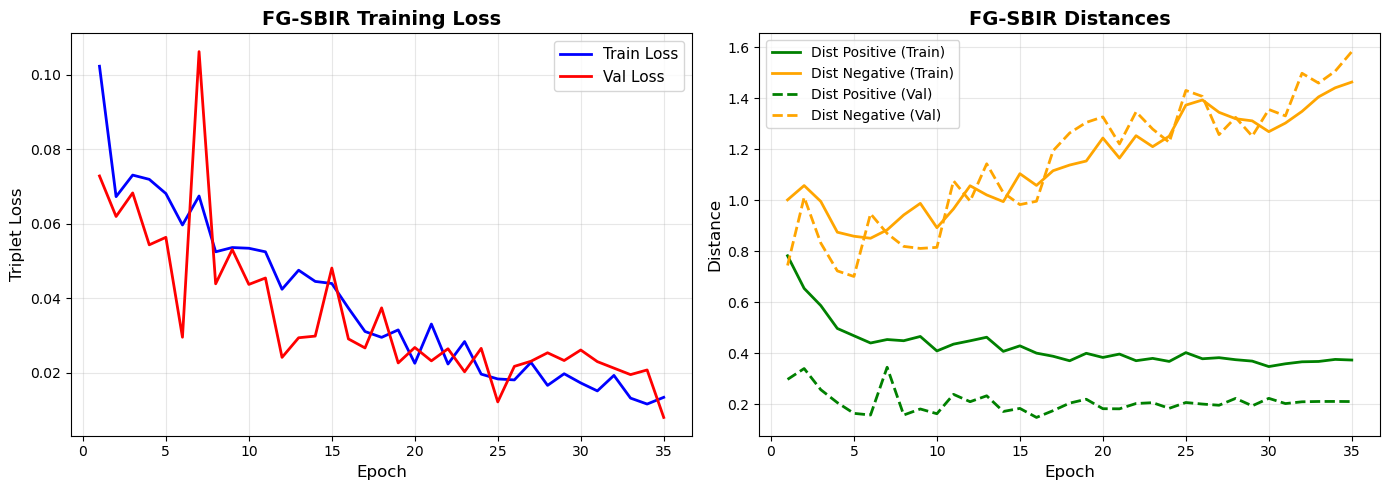

📊 STATISTIQUES FINALES

📈 Loss:
   Train final: 0.0133
   Val final:   0.0079
   Meilleur val: 0.0079 (epoch 35)

📏 Distances (dernière epoch):
   Positive (train): 0.373
   Negative (train): 1.463
   Marge effective:  1.090

📏 Distances (validation):
   Positive (val): 0.211
   Negative (val): 1.582
   Marge effective: 1.372

✅ CRITÈRES DE QUALITÉ
✅ Loss < 0.1 (excellent)
✅ Marge = 1.372 > 0.3 (excellent)
✅ Train-Val gap = 0.005 (pas d'overfitting)
⚠️  Amélioration récente: 0.014 (peut continuer)

🎉 MODÈLE BIEN ENTRAÎNÉ - Prêt à utiliser!


In [58]:
# ============================================================
# VISUALISER L'HISTORIQUE D'ENTRAÎNEMENT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle
import torch

def safe_torch_load(path, map_location='cpu', trusted_source=True):
    """
    PyTorch >= 2.6: weights_only=True par défaut.
    Tente d'abord le chargement sûr, puis fallback explicite si source fiable.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except pickle.UnpicklingError as e:
        print(f"⚠️ Chargement sûr échoué: {e}")
        if not trusted_source:
            raise
        print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
        return torch.load(path, map_location=map_location, weights_only=False)

def plot_fgsbir_history(checkpoint_path):
    """Visualise les courbes d'entraînement FG-SBIR"""
    
    checkpoint = safe_torch_load(checkpoint_path, map_location='cpu', trusted_source=True)
    history = checkpoint['history']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 1. Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Triplet Loss', fontsize=12)
    axes[0].set_title('FG-SBIR Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Distances
    axes[1].plot(epochs, history['train_dist_pos'], 'g-', label='Dist Positive (Train)', linewidth=2)
    axes[1].plot(epochs, history['train_dist_neg'], 'orange', label='Dist Negative (Train)', linewidth=2)
    axes[1].plot(epochs, history['val_dist_pos'], 'g--', label='Dist Positive (Val)', linewidth=2)
    axes[1].plot(epochs, history['val_dist_neg'], 'orange', linestyle='--', label='Dist Negative (Val)', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Distance', fontsize=12)
    axes[1].set_title('FG-SBIR Distances', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('fgsbir_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Stats finales
    print("="*60)
    print("📊 STATISTIQUES FINALES")
    print("="*60)
    print(f"\n📈 Loss:")
    print(f"   Train final: {history['train_loss'][-1]:.4f}")
    print(f"   Val final:   {history['val_loss'][-1]:.4f}")
    print(f"   Meilleur val: {min(history['val_loss']):.4f} (epoch {np.argmin(history['val_loss'])+1})")
    
    print(f"\n📏 Distances (dernière epoch):")
    print(f"   Positive (train): {history['train_dist_pos'][-1]:.3f}")
    print(f"   Negative (train): {history['train_dist_neg'][-1]:.3f}")
    print(f"   Marge effective:  {history['train_dist_neg'][-1] - history['train_dist_pos'][-1]:.3f}")
    
    print(f"\n📏 Distances (validation):")
    print(f"   Positive (val): {history['val_dist_pos'][-1]:.3f}")
    print(f"   Negative (val): {history['val_dist_neg'][-1]:.3f}")
    print(f"   Marge effective: {history['val_dist_neg'][-1] - history['val_dist_pos'][-1]:.3f}")
    
    # Critères de qualité
    print("\n" + "="*60)
    print("✅ CRITÈRES DE QUALITÉ")
    print("="*60)
    
    checks = []
    
    # 1. Loss converge
    if history['val_loss'][-1] < 0.1:
        checks.append(("✅", "Loss < 0.1 (excellent)"))
    elif history['val_loss'][-1] < 0.15:
        checks.append(("✅", "Loss < 0.15 (bon)"))
    elif history['val_loss'][-1] < 0.20:
        checks.append(("⚠️ ", "Loss < 0.20 (acceptable, peut être amélioré)"))
    else:
        checks.append(("❌", f"Loss = {history['val_loss'][-1]:.3f} (trop élevé)"))
    
    # 2. Marge positive/negative
    margin = history['val_dist_neg'][-1] - history['val_dist_pos'][-1]
    if margin > 0.3:
        checks.append(("✅", f"Marge = {margin:.3f} > 0.3 (excellent)"))
    elif margin > 0.2:
        checks.append(("✅", f"Marge = {margin:.3f} > 0.2 (bon)"))
    elif margin > 0.1:
        checks.append(("⚠️ ", f"Marge = {margin:.3f} > 0.1 (acceptable)"))
    else:
        checks.append(("❌", f"Marge = {margin:.3f} (trop faible)"))
    
    # 3. Pas d'overfitting
    gap = history['train_loss'][-1] - history['val_loss'][-1]
    if abs(gap) < 0.02:
        checks.append(("✅", f"Train-Val gap = {gap:.3f} (pas d'overfitting)"))
    elif abs(gap) < 0.05:
        checks.append(("⚠️ ", f"Train-Val gap = {gap:.3f} (léger overfitting)"))
    else:
        checks.append(("❌", f"Train-Val gap = {gap:.3f} (overfitting)"))
    
    # 4. Convergence
    if len(history['val_loss']) >= 10:
        recent_improvement = history['val_loss'][-10] - history['val_loss'][-1]
        if recent_improvement < 0.01:
            checks.append(("✅", "Convergé (pas d'amélioration récente)"))
        else:
            checks.append(("⚠️ ", f"Amélioration récente: {recent_improvement:.3f} (peut continuer)"))
    
    for symbol, message in checks:
        print(f"{symbol} {message}")
    
    # Verdict final
    print("\n" + "="*60)
    n_good = sum(1 for s, _ in checks if s == "✅")
    if n_good >= 3:
        print("🎉 MODÈLE BIEN ENTRAÎNÉ - Prêt à utiliser!")
    elif n_good >= 2:
        print("👍 MODÈLE ACCEPTABLE - Peut être utilisé")
    else:
        print("⚠️  MODÈLE SOUS-OPTIMAL - Entraîner plus longtemps recommandé")
    print("="*60)

# Utiliser
plot_fgsbir_history('/Data/arthur.buis/checkpoints_fgsbir/fgsbir_best.pt')

⚠️ Chargement sûr échoué: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mo

Encoding photos: 100%|██████████| 100/100 [00:00<00:00, 210.10it/s]


   ✅ 100 photos encodées

🔍 Recherche des photos similaires...


/tmp/ipykernel_2343869/1805326394.py:122: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2343869/1805326394.py:123: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('fgsbir_retrieval_test.png', dpi=150, bbox_inches='tight')
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


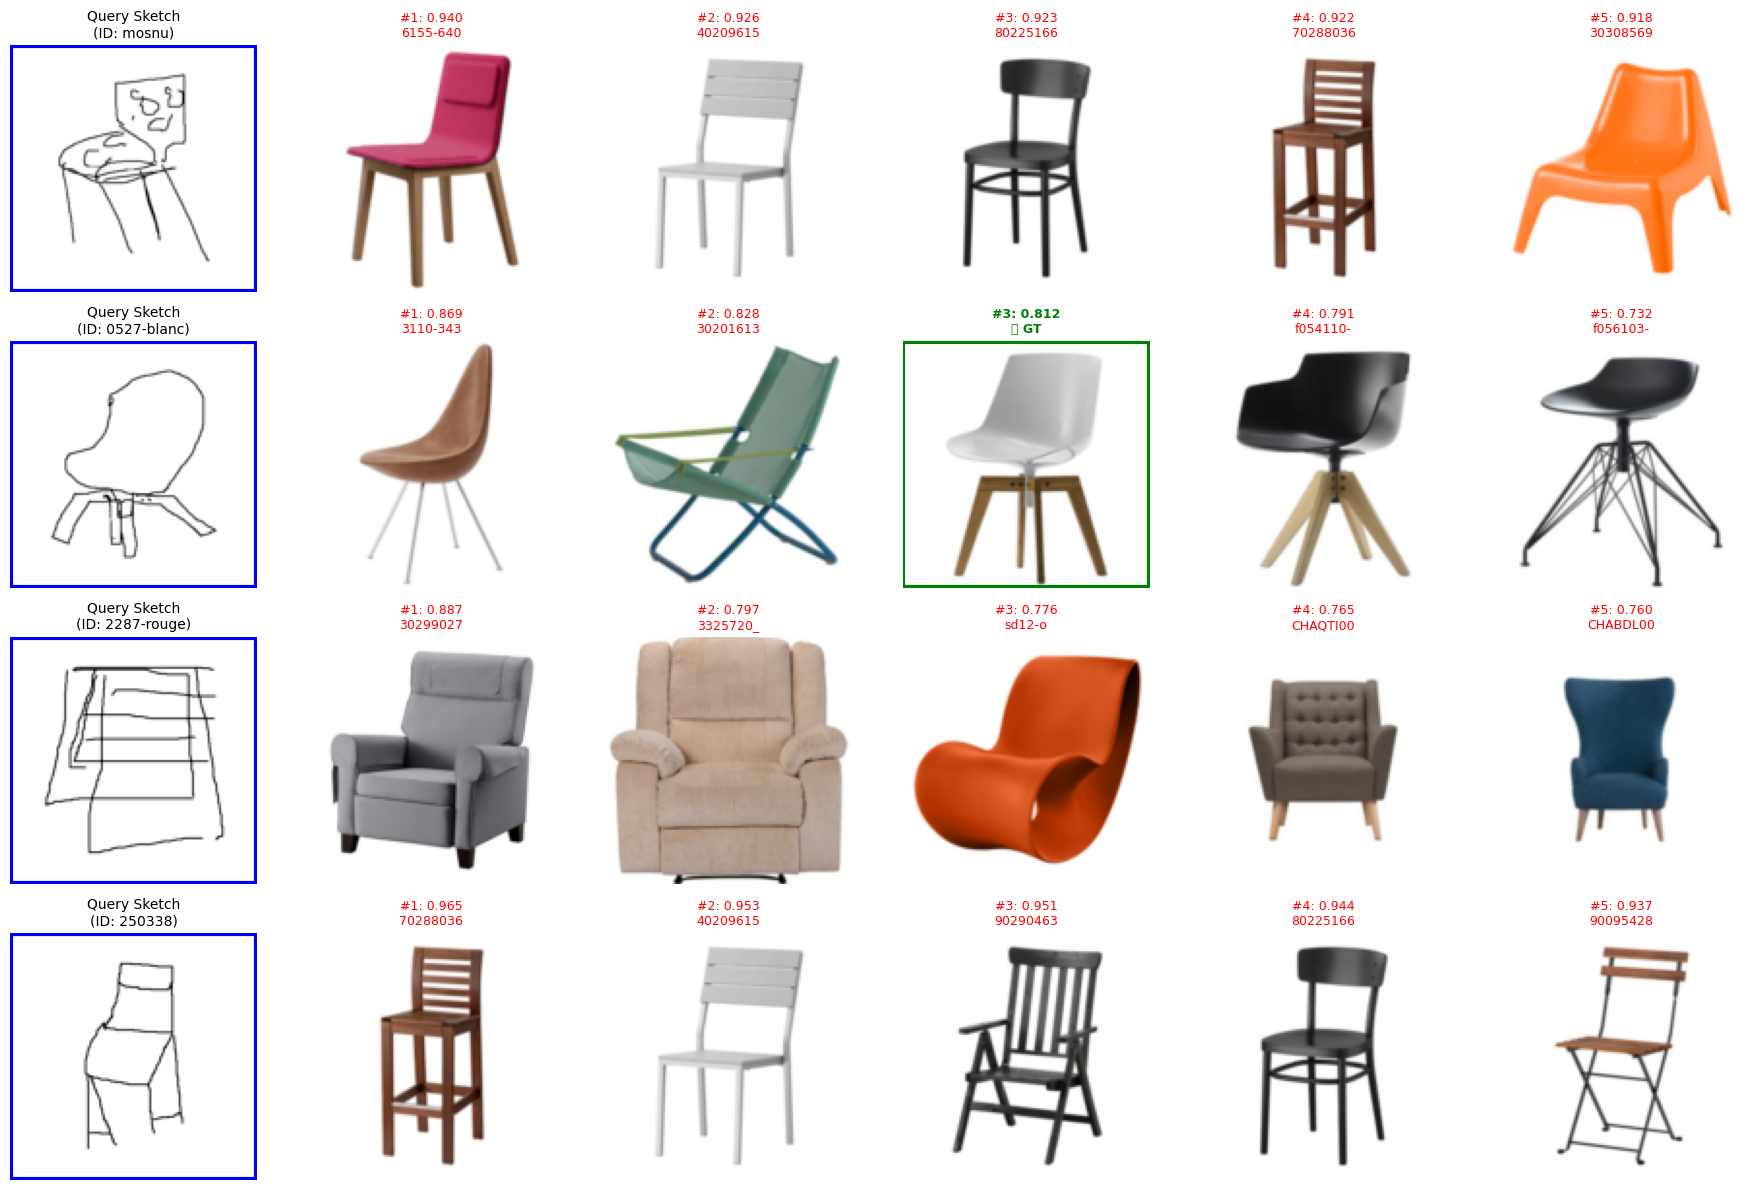


✅ Test de retrieval sauvegardé: fgsbir_retrieval_test.png

💡 Interprétation:
   - Cadre VERT = Ground truth trouvée (✅ excellent)
   - Position #1 = Meilleure similarité
   - Score proche de 1.0 = Très similaire


In [59]:
# ============================================================
# TEST VISUEL: RETRIEVAL SKETCH → PHOTO
# ============================================================

import pickle
import torch

def safe_torch_load(path, map_location='cpu', trusted_source=True):
    """Compatibilité PyTorch >= 2.6 pour les checkpoints legacy."""
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except pickle.UnpicklingError as e:
        print(f"⚠️ Chargement sûr échoué: {e}")
        if not trusted_source:
            raise
        print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
        return torch.load(path, map_location=map_location, weights_only=False)

def test_fgsbir_retrieval(fgsbir_model, dataset_root, n_queries=4, n_results=5, device=None):
    """
    Teste la qualité du retrieval:
    Pour chaque sketch, trouve les photos les plus similaires
    """
    
    if device is None:
        device = next(fgsbir_model.parameters()).device
    
    # Dataset
    dataset = ChairV2Dataset(dataset_root, 'test', 128, False)
    
    # Prendre quelques sketches aléatoires
    np.random.seed(42)
    query_indices = np.random.choice(len(dataset), n_queries, replace=False)
    
    # Encoder TOUTES les photos du dataset
    print("🔄 Encodage de toutes les photos...")
    
    fgsbir_model.eval()
    
    all_photo_embeddings = []
    all_photo_tensors = []
    all_photo_ids = []
    
    # Créer dataset de photos uniques
    unique_photos = {}
    for i in range(len(dataset)):
        item = dataset[i]
        photo_id = item['photo_id']
        if photo_id not in unique_photos:
            unique_photos[photo_id] = item['photo']
    
    photo_list = list(unique_photos.items())
    
    with torch.no_grad():
        for photo_id, photo_tensor in tqdm(photo_list, desc="Encoding photos"):
            photo_emb = fgsbir_model.forward_photo(photo_tensor.unsqueeze(0).to(device))
            all_photo_embeddings.append(photo_emb.cpu())
            all_photo_tensors.append(photo_tensor)
            all_photo_ids.append(photo_id)
    
    all_photo_embeddings = torch.cat(all_photo_embeddings, dim=0)
    
    print(f"   ✅ {len(all_photo_embeddings)} photos encodées")
    
    # Pour chaque query sketch
    fig, axes = plt.subplots(n_queries, n_results + 1, figsize=(3*(n_results+1), 3*n_queries))
    
    if n_queries == 1:
        axes = axes.reshape(1, -1)
    
    print("\n🔍 Recherche des photos similaires...")
    
    with torch.no_grad():
        for q_idx, query_idx in enumerate(query_indices):
            query_item = dataset[query_idx]
            query_sketch = query_item['sketch']
            query_photo_id = query_item['photo_id']
            
            # Encoder sketch
            sketch_emb = fgsbir_model.forward_sketch(query_sketch.unsqueeze(0).to(device))
            
            # Calculer similarités avec toutes les photos
            similarities = F.cosine_similarity(
                sketch_emb.cpu(),
                all_photo_embeddings,
                dim=1
            )
            
            # Top-K
            top_k_indices = torch.topk(similarities, k=n_results).indices
            
            # Afficher sketch query
            sketch_np = (query_sketch.numpy() + 1) / 2
            axes[q_idx, 0].imshow(sketch_np.squeeze(), cmap='gray')
            axes[q_idx, 0].set_title(f'Query Sketch\n(ID: {query_photo_id})', fontsize=10)
            axes[q_idx, 0].axis('off')
            axes[q_idx, 0].add_patch(plt.Rectangle((0, 0), 127, 127, fill=False, 
                                                    edgecolor='blue', linewidth=3))
            
            # Afficher top résultats
            for rank, idx in enumerate(top_k_indices):
                photo_tensor = all_photo_tensors[idx]
                photo_id = all_photo_ids[idx]
                sim_score = similarities[idx].item()
                
                photo_np = (photo_tensor.numpy().transpose(1, 2, 0) + 1) / 2
                
                axes[q_idx, rank + 1].imshow(photo_np)
                
                # Marquer si c'est la bonne photo (ground truth)
                is_correct = (photo_id == query_photo_id)
                color = 'green' if is_correct else 'red'
                title = f"#{rank+1}: {sim_score:.3f}\n{'✅ GT' if is_correct else photo_id[:8]}"
                
                axes[q_idx, rank + 1].set_title(title, fontsize=9, color=color, fontweight='bold' if is_correct else 'normal')
                axes[q_idx, rank + 1].axis('off')
                
                if is_correct:
                    axes[q_idx, rank + 1].add_patch(plt.Rectangle((0, 0), 127, 127, fill=False, 
                                                                   edgecolor='green', linewidth=3))
    
    plt.tight_layout()
    plt.savefig('fgsbir_retrieval_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Test de retrieval sauvegardé: fgsbir_retrieval_test.png")
    print("\n💡 Interprétation:")
    print("   - Cadre VERT = Ground truth trouvée (✅ excellent)")
    print("   - Position #1 = Meilleure similarité")
    print("   - Score proche de 1.0 = Très similaire")

# Charger modèle
device = 'cuda' if torch.cuda.is_available() else 'cpu'
fgsbir_checkpoint = safe_torch_load('/Data/arthur.buis/checkpoints_fgsbir/fgsbir_best.pt', map_location=device, trusted_source=True)
fgsbir_model = FGSBIRModel(embedding_dim=512).to(device)
fgsbir_model.load_state_dict(fgsbir_checkpoint['model_state_dict'])
fgsbir_model.eval()

# Tester
test_fgsbir_retrieval(
    fgsbir_model,
    dataset_root='/Data/arthur.buis/pairs-sketch/ChairV2',
    n_queries=4,
    n_results=5,
    device=device
)

# Entrainement du Sketch Mapper - 6700 epochs papier

In [60]:
import torch
import torchvision.utils as vutils
from pathlib import Path


@torch.no_grad()
def run_inference_grid(sketch_mapper, G, val_loader, device, save_path, n=8):
    """
    Sauvegarde une grille : sketch | gen@3steps | gen@6steps | gen@10steps | gt_photo
    """
    from torchvision.utils import save_image

    sketch_mapper.eval()
    batch  = next(iter(val_loader))
    sketch = batch['anchor_sketch'][:n].to(device)
    photo  = batch['positive_photo'][:n].to(device)

    rows = []
    for steps in [3, 6, 10]:
        w_plus, _ = sketch_mapper(sketch, num_steps=steps)
        gen = G.synthesis(w_plus, noise_mode="const")
        gen = (gen.clamp(-1, 1) + 1) / 2.0
        rows.append(gen)

    # Sketch en RGB pour affichage
    sk = sketch.repeat(1, 3, 1, 1) if sketch.size(1) == 1 else sketch
    sk = (sk - sk.min()) / (sk.max() - sk.min() + 1e-8)

    grid = torch.cat([sk, rows[0], rows[1], rows[2], photo], dim=0)
    save_image(grid, save_path, nrow=n, padding=2)
    print(f"   🖼  Grille sauvegardée → {save_path}")
    sketch_mapper.train()

In [61]:
@torch.no_grad()
def validate(sketch_mapper, photo_mapper, val_loader, kd_loss, device):
    sketch_mapper.eval()
    total = 0.0
    for batch in val_loader:
        sketches = batch['anchor_sketch'].to(device)
        photos   = batch['positive_photo'].to(device)
        _, latent_sketch = sketch_mapper(sketches)
        _, latent_photo  = photo_mapper(photos)
        latent_photo     = latent_photo[:, :latent_sketch.size(1), :]
        total += kd_loss(latent_sketch, latent_photo).item()
    sketch_mapper.train()
    return total / len(val_loader)

In [62]:
def save_checkpoint(epoch, model, optimizer, best_val, path):
    torch.save({
        "epoch":       epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "best_val":    best_val,
    }, path)

In [63]:
def _init_from_photomapper(sketch_mapper, photo_mapper):
    """Copie les poids compatibles du PhotoMapper dans le SketchMapper."""
    pm_state, sm_state = photo_mapper.state_dict(), sketch_mapper.state_dict()
    transferred = 0
    for k, v in pm_state.items():
        if k in sm_state and sm_state[k].shape == v.shape:
            sm_state[k] = v.clone()
            transferred += 1
    sketch_mapper.load_state_dict(sm_state)
    print(f"📥 PhotoMapper → SketchMapper : {transferred} couches transférées")

In [64]:
def _save_ckpt(path, epoch, model, optimizer, best_val, phase=None):
    # Lookahead wrapping RAdam : récupérer l'optimizer de base pour la sérialisation
    optim_to_save = getattr(optimizer, 'optimizer', optimizer)
    torch.save({
        "epoch":       epoch,
        "model_state": model.state_dict(),
        "optim_state": optim_to_save.state_dict(),
        "best_val":    best_val,
        "phase":       phase,
    }, path)

In [65]:
def _load_ckpt(path, model, optimizer, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    
    # Charger dans l'optimizer de base (RAdam), pas dans le Lookahead wrapper
    base_optim = getattr(optimizer, 'optimizer', optimizer)
    base_optim.load_state_dict(ckpt["optim_state"])
    
    epoch    = ckpt.get("epoch", 0)
    best_val = ckpt.get("best_val", float("inf"))
    phase    = ckpt.get("phase", "non définie")
    print(f"🔄 Checkpoint chargé : epoch={epoch}, best_val={best_val:.6f}, phase={phase}")
    return epoch + 1, best_val

In [66]:
@torch.no_grad()
def _inference_grid(sketch_mapper, G, val_loader, device, save_path, n=8):
    """Grille : sketch | gen@3steps | gen@6steps | gen@10steps | gt_photo"""
    from torchvision.utils import save_image
    sketch_mapper.eval()
    batch = next(iter(val_loader))
    p = batch['positive_photo']
    print(f"min={p.min():.3f}  max={p.max():.3f}  mean={p.mean():.3f}")
    sketch = batch['anchor_sketch'][:n].to(device)
    photo  = batch['positive_photo'][:n].to(device)

    rows = []
    for steps in [3, 6, 10]:
        w_plus, _ = sketch_mapper(sketch, num_steps=steps)
        gen = G.synthesis(w_plus, noise_mode="const")
        rows.append((gen.clamp(-1, 1) + 1) / 2.0)

    sk = sketch.repeat(1, 3, 1, 1) if sketch.size(1) == 1 else sketch
    sk = (sk - sk.min()) / (sk.max() - sk.min() + 1e-8)
    ph = (photo.clamp(-1, 1) + 1) / 2.0 if photo.min() < 0 else photo

    save_image(torch.cat([sk, *rows, ph], dim=0), save_path, nrow=n, padding=2)
    print(f"   🖼  {save_path}")
    sketch_mapper.train()

In [67]:
# ─────────────────────────────────────────────────────────────────────────────
#  VERSION 1 — KD loss uniquement
# ─────────────────────────────────────────────────────────────────────────────

def train_sketch_mapper_kd(
    dataset_root,
    photomapper_path,
    stylegan_dir,
    output_dir,
    epochs=500,
    batch_size=4,
    lr=1e-4,
    device="cuda",
    val_every=20,
    inference_every=20,
    resume_path=None,         # reprendre depuis un checkpoint
    init_from_photomapper=True,  # copier les poids du PhotoMapper au démarrage
):
    from torch.utils.data import DataLoader

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # DATASETS
    # --------------------------------------------------

    train_loader = DataLoader(TripletChairDataset(dataset_root, "train", 128),
                              batch_size=batch_size, shuffle=True,  num_workers=4)
    val_loader   = DataLoader(TripletChairDataset(dataset_root, "test",  128),
                              batch_size=batch_size, shuffle=False, num_workers=4)

    # --------------------------------------------------
    # MODELS
    # --------------------------------------------------

    sketch_mapper = SketchMapper().to(device)

    photo_mapper = PhotoMapper().to(device)
    ckpt = torch.load(photomapper_path, map_location=device)
    photo_mapper.load_state_dict(ckpt["model_state_dict"])
    photo_mapper.eval()
    for p in photo_mapper.parameters():
        p.requires_grad = False

    G = load_stylegan(stylegan_dir, device)


    # --------------------------------------------------
    # INIT POIDS + REPRISE
    # --------------------------------------------------

    try:
        import torch_optimizer as optim_extra
        base_optimizer = optim_extra.RAdam(sketch_mapper.parameters(), lr=lr)
        optimizer = optim_extra.Lookahead(base_optimizer, k=5, alpha=0.5)
    except ImportError:
        # Fallback : RAdam natif PyTorch sans Lookahead
        print("⚠️  torch-optimizer non installé, fallback RAdam (pip install torch-optimizer)")
        optimizer = torch.optim.RAdam(sketch_mapper.parameters(), lr=lr)
    start_epoch, best_val = 1, float("inf")

    if resume_path is not None and Path(resume_path).exists():
        start_epoch, best_val = _load_ckpt(resume_path, sketch_mapper, optimizer, device)
    elif not Path(photomapper_path).exists():
        print(f"❌ Le fichier {photomapper_path} n'existe pas.")
    elif init_from_photomapper:
        _init_from_photomapper(sketch_mapper, photo_mapper)

    # --------------------------------------------------
    # LOSS
    # --------------------------------------------------

    kd_loss = torch.nn.MSELoss()

    # --------------------------------------------------
    # TRAIN LOOP
    # --------------------------------------------------

    for epoch in range(start_epoch, epochs + 1):

        sketch_mapper.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            sketches = batch['anchor_sketch'].to(device)
            photos   = batch['positive_photo'].to(device)

            optimizer.zero_grad()

            _, latent_sketch = sketch_mapper(sketches)
            with torch.no_grad():
                latent_photo = photo_mapper(photos)
                latent_photo = latent_photo[:, :latent_sketch.size(1), :]

            loss = kd_loss(latent_sketch, latent_photo)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(sketch_mapper.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({"KD": f"{loss.item():.6f}"})

        train_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch}/{epochs} | KD loss: {train_loss:.6f}")

        # --------------------------------------------------
        # VALIDATION
        # --------------------------------------------------

        if epoch % val_every == 0 or epoch ==1:
            sketch_mapper.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in tqdm(val_loader, desc="  Validation", leave=False):
                    sketches = batch['anchor_sketch'].to(device)
                    photos   = batch['positive_photo'].to(device)
                    _, ls = sketch_mapper(sketches)
                    lp = photo_mapper(photos)
                    val_loss += kd_loss(ls, lp[:, :ls.size(1), :]).item()
            val_loss /= len(val_loader)
            sketch_mapper.train()

            print(f"   [VAL] KD loss: {val_loss:.6f}")

            if val_loss < best_val:
                best_val = val_loss
                _save_ckpt(output_dir / "best_distill.pt",
                           epoch, sketch_mapper, optimizer, best_val)
                print(f"   💾 best_distill.pt (val={best_val:.6f})")

        # --------------------------------------------------
        # INFERENCE VISUELLE
        # --------------------------------------------------

        if epoch % inference_every == 0 or epoch ==start_epoch:
            _inference_grid(sketch_mapper, G, val_loader, device,
                            output_dir / f"inference_{epoch}.png")

        # --------------------------------------------------
        # CHECKPOINT PÉRIODIQUE
        # --------------------------------------------------

        if epoch % 50 == 0  or epoch ==start_epoch:
            _save_ckpt(output_dir / f"ckpt_{epoch}.pt",
                       epoch, sketch_mapper, optimizer, best_val)

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
#  VERSION 2 — SketchMapperLoss complète (Lrec + LLPIPS + Ldisc + LKD)
# ─────────────────────────────────────────────────────────────────────────────

def train_sketch_mapper_full(
    dataset_root,
    photomapper_path,
    stylegan_dir,
    output_dir,
    loss_fn,                     # instance de SketchMapperLoss déjà construite
    epochs=200,
    batch_size=32,
    lr=1e-5,
    device="cuda",
    val_every=10,
    inference_every=20,
    resume_path=None,
    init_from_photomapper=False,
):
    """
    loss_fn est une instance de SketchMapperLoss.
    Son forward(sketch, photo_real, photo_generated, predicted_latents, teacher_latents)
    retourne un dict {'rec', 'lpips', 'disc', 'kd', 'total'}.
    StyleGAN génère photo_generated à partir des latents du SketchMapper.
    """
    from torch.utils.data import DataLoader
    import pickle

    def _safe_torch_load(path, map_location='cpu', trusted_source=True):
        try:
            return torch.load(path, map_location=map_location, weights_only=True)
        except pickle.UnpicklingError as e:
            print(f"⚠️ Chargement sûr échoué: {e}")
            if not trusted_source:
                raise
            print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
            return torch.load(path, map_location=map_location, weights_only=False)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # DATASETS
    # --------------------------------------------------

    train_loader = DataLoader(TripletChairDataset(dataset_root, "train", 128),
                              batch_size=batch_size, shuffle=True,  num_workers=4)
    val_loader   = DataLoader(TripletChairDataset(dataset_root, "test",  128),
                              batch_size=batch_size, shuffle=False, num_workers=4)

    # --------------------------------------------------
    # MODELS
    # --------------------------------------------------

    sketch_mapper = SketchMapper().to(device)

    photo_mapper = PhotoMapper().to(device)
    ckpt = _safe_torch_load(photomapper_path, map_location=device, trusted_source=True)
    photo_mapper.load_state_dict(ckpt["model_state_dict"])
    photo_mapper.eval()
    for p in photo_mapper.parameters():
        p.requires_grad = False

    G = load_stylegan(stylegan_dir, device)

    
    # --------------------------------------------------
    # INIT POIDS + REPRISE
    # --------------------------------------------------

    try:
        import torch_optimizer as optim_extra
        base_optimizer = optim_extra.RAdam(sketch_mapper.parameters(), lr=lr)
        optimizer = optim_extra.Lookahead(base_optimizer, k=5, alpha=0.5)
    except ImportError:
        # Fallback : RAdam natif PyTorch sans Lookahead
        print("⚠️  torch-optimizer non installé, fallback RAdam (pip install torch-optimizer)")
        optimizer = torch.optim.RAdam(sketch_mapper.parameters(), lr=lr)
        
    start_epoch, best_val = 1, float("inf")

    if resume_path is not None and Path(resume_path).exists():
        ckpt = _safe_torch_load(resume_path, map_location=device, trusted_source=True)
        sketch_mapper.load_state_dict(ckpt["model_state"])
        if ckpt.get("phase") == "finetune":
            base_optim = getattr(optimizer, 'optimizer', optimizer)  # ← fix
            base_optim.load_state_dict(ckpt["optim_state"])
            start_epoch = ckpt["epoch"] + 1
            best_val    = ckpt.get("best_val", float("inf"))
        print(f"🔄 Reprise depuis {resume_path} (epoch {ckpt.get('epoch', '?')})")
    elif init_from_photomapper:
        _init_from_photomapper(sketch_mapper, photo_mapper)

    # --------------------------------------------------
    # TRAIN LOOP
    # --------------------------------------------------

    for epoch in range(start_epoch, epochs + 1):

        sketch_mapper.train()
        accum = {}
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            sketches = batch['anchor_sketch'].to(device)
            photos   = batch['positive_photo'].to(device)

            optimizer.zero_grad()

            # Forward SketchMapper → StyleGAN
            w_plus, latent_sketch = sketch_mapper(sketches)
            with torch.no_grad():
                photo_gen = G.synthesis(w_plus.detach(), noise_mode="const")
                photo_gen = (photo_gen.clamp(-1, 1) + 1) / 2.0

            # Teacher latents (frozen PhotoMapper)
            with torch.no_grad():
                latent_photo = photo_mapper(photos)
                latent_photo    = latent_photo[:, :latent_sketch.size(1), :]

            # GT photo dans [0, 1]
            photos_01 = (photos.clamp(-1, 1) + 1) / 2.0 if photos.min() < 0 else photos

            # SketchMapperLoss.forward retourne un dict directement
            losses = loss_fn(
                sketch            = sketches,
                photo_real        = photos_01,
                photo_generated   = photo_gen,
                predicted_latents = latent_sketch,
                teacher_latents   = latent_photo,
            )

            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(sketch_mapper.parameters(), 1.0)
            optimizer.step()

            for k, v in losses.items():
                accum[k] = accum.get(k, 0.0) + v.item()

        avg = {k: v / len(train_loader) for k, v in accum.items()}
        print(f"Epoch {epoch}/{epochs} | " +
              "  ".join(f"{k}={v:.4f}" for k, v in avg.items()))

        # --------------------------------------------------
        # VALIDATION
        # --------------------------------------------------

        if epoch % val_every == 0:
            sketch_mapper.eval()
            val_total = 0.0
            with torch.no_grad():
                for batch in tqdm(val_loader, desc="  Validation", leave=False):
                    sketches  = batch['anchor_sketch'].to(device)
                    photos    = batch['positive_photo'].to(device)
                    w_plus, ls = sketch_mapper(sketches)
                    photo_gen  = G.synthesis(w_plus, noise_mode="const")
                    photo_gen  = (photo_gen.clamp(-1, 1) + 1) / 2.0
                    lp      = photo_mapper(photos)
                    lp         = lp[:, :ls.size(1), :]
                    photos_01  = (photos.clamp(-1, 1) + 1) / 2.0 if photos.min() < 0 else photos
                    losses     = loss_fn(sketches, photos_01, photo_gen, ls, lp)
                    val_total += losses['total'].item()
            val_total /= len(val_loader)
            sketch_mapper.train()

            print(f"   [VAL] total={val_total:.4f}")

            if val_total < best_val:
                best_val = val_total
                _save_ckpt(output_dir / "best_finetune.pt",
                           epoch, sketch_mapper, optimizer, best_val, phase="finetune")
                print(f"   💾 best_finetune.pt (val={best_val:.4f})")

        # --------------------------------------------------
        # INFERENCE VISUELLE
        # --------------------------------------------------

        if epoch % inference_every == 0 or epoch ==start_epoch:
            _inference_grid(sketch_mapper, G, val_loader, device,
                            output_dir / f"inference_ft_{epoch}.png")

        # --------------------------------------------------
        # CHECKPOINT PÉRIODIQUE
        # --------------------------------------------------

        if epoch % 50 == 0 or epoch ==start_epoch:
            _save_ckpt(output_dir / f"ckpt_ft_{epoch}.pt",
                       epoch, sketch_mapper, optimizer, best_val, phase="finetune")


In [69]:
# dataset_root = '/Data/arthur.buis/pairs-sketch/ChairV2'
# stylegan_checkpoint = '/Data/arthur.buis/stylegan3_training_chairs/network-snapshot-032000.pkl'
# photo_mapper_checkpoint = '/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000_CORRECTED.pt'
# fgsbir_checkpoint ='/Data/arthur.buis/checkpoints_fgsbir/fgsbir_best.pt'
# resume_checkpoint = '/Data/arthur.buis/checkpoints_sketch_mapper_radam/sketch_mapper_best.pt'
# resume_path = '/Data/arthur.buis/sketchmapper_fullreworked/ckpt_200.pt'  # ou None pour démarrer sans reprise

# #Step 0 -- training only KD
# train_sketch_mapper_kd(
#     dataset_root=dataset_root,
#     photomapper_path=photo_mapper_checkpoint,
#     stylegan_dir=stylegan_checkpoint,
#     output_dir="/Data/arthur.buis/sketchmapper_fullreworked",

#     epochs = 1000,
#     batch_size=4,
#     lr=1e-4,
#     device="cuda",
#     val_every=20,
#     inference_every=20,
#     resume_path=resume_path,
#     init_from_photomapper=False,
# )

 Suite de la stratégie : \
 Étape A : KD + Lrec seulement (lambda_lpips=0, lambda_disc=0)
          → stabilise la reconstruction pixel d'abord

Étape B : KD + Lrec + LLPIPS
          → améliore la qualité perceptuelle

Étape C : tous les termes (+ Ldisc avec FG-SBIR)
          → affine la cohérence sketch↔photo

Fin du step 0: '/Data/roman.lendormy/sketchmapper_fullreworked/ckpt_400.pt'

In [ ]:
dataset_root = '/Data/arthur.buis/pairs-sketch/ChairV2'
stylegan_checkpoint = '/users/eleves-b/2023/arthur.buis/Documents/CSC_52002_Multimodal_Generative_AI/Project/stylegan3_training_chairs/network-snapshot-006400.pkl'
photo_mapper_checkpoint = '/Data/arthur.buis/checkpoints_photo_mapper/photo_mapper_32000.pt'
fgsbir_checkpoint ='/Data/arthur.buis/checkpoints_fgsbir/fgsbir_best.pt'
resume_checkpoint = '/Data/arthur.buis/checkpoints_sketch_mapper_radam/sketch_mapper_best.pt'
resume_path = '/Data/arthur.buis/sketchmapper_fullreworked_stepB/ckpt_ft_550.pt'  # ou None pour démarrer sans reprise


import lpips
import pickle

def safe_torch_load(path, map_location='cpu', trusted_source=True):
    """Compatibilité PyTorch >= 2.6 pour les checkpoints legacy."""
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except pickle.UnpicklingError as e:
        print(f"⚠️ Chargement sûr échoué: {e}")
        if not trusted_source:
            raise
        print("🔓 Fallback: torch.load(..., weights_only=False) car source de confiance")
        return torch.load(path, map_location=map_location, weights_only=False)

lpips_net = lpips.LPIPS(net='vgg').to('cuda')
lpips_net.eval()
for p in lpips_net.parameters():
    p.requires_grad = False

fgsbir = FGSBIRModel().to('cuda')
ckpt_fg = safe_torch_load(fgsbir_checkpoint, map_location='cuda', trusted_source=True)
fgsbir.load_state_dict(ckpt_fg.get('model_state_dict') or ckpt_fg.get('model_state') or ckpt_fg)
fgsbir.eval()
for p in fgsbir.parameters():
    p.requires_grad = False

loss_fn = SketchMapperLoss(
    lpips_net    = lpips_net,
    fgsbir_model = fgsbir,
    lambda_rec   = 1.0,
    lambda_lpips = 0.8,   # Step A : désactivé
    lambda_disc  = 0.5,   # Step A : désactivé
    lambda_kd    = 0.6,
)


# #Step 0 -- training only KD
# train_sketch_mapper_full(
#     dataset_root=dataset_root,
#     photomapper_path=photo_mapper_checkpoint,
#     stylegan_dir=stylegan_checkpoint,
#     output_dir="/Data/arthur.buis/sketchmapper_fullreworked_stepB",
#     loss_fn = loss_fn,
#     epochs = 1000,
#     batch_size=4,
#     lr=1e-5,
#     device="cuda",
#     val_every=20,
#     inference_every=20,
#     resume_path=resume_path,
#     init_from_photomapper=False,
# )

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/users/eleves-b/2023/arthur.buis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /users/eleves-b/2023/arthur.buis/.local/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
⚠️ Chargement sûr échoué: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context m

KeyboardInterrupt: 

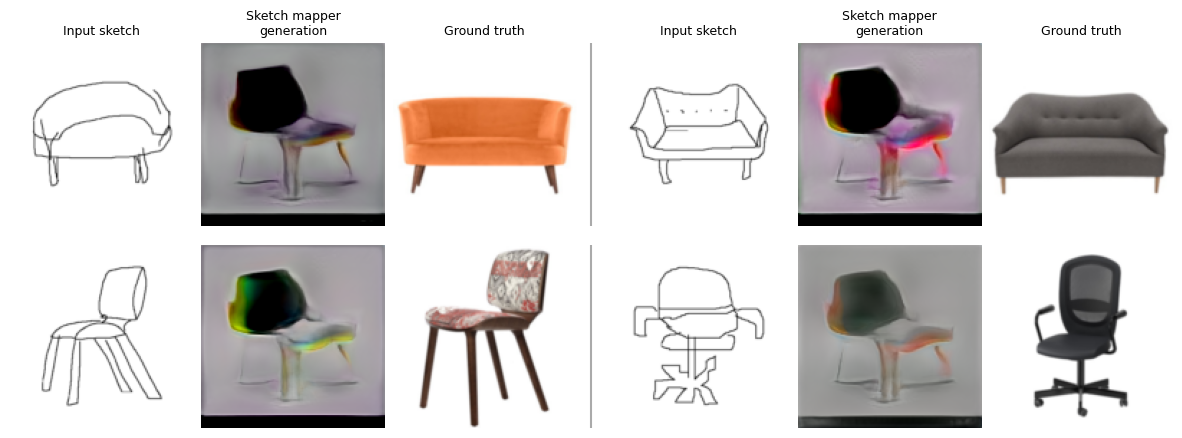

In [ ]:

# ============================================================
# TEST VISUEL : sketch → génération vs ground truth
# ============================================================
import random
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

_N = 4
_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

indices = random.sample(range(len(test_ds)), k=_N)
samples = [test_ds[i] for i in indices]

sketches = torch.stack([s['sketch'] for s in samples]).to(_DEVICE)
photos   = torch.stack([s['photo']  for s in samples]).to(_DEVICE)

def _to_rgb(t):
    img = t.cpu().float()
    if img.min() < -0.1:
        img = (img + 1) / 2
    img = img.clamp(0, 1)
    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)
    return img.permute(1, 2, 0).numpy()

sketch_mapper.eval()
with torch.no_grad():
    w_plus, _ = sketch_mapper(sketches)
    generated = G.synthesis(w_plus, noise_mode='const').clamp(-1, 1)

col_labels = ['Input sketch', 'Sketch mapper\ngeneration', 'Ground truth']

# GridSpec: 2 rows, 7 cols (col 3 is the separator)
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(2, 7, figure=fig,
                       width_ratios=[1, 1, 1, 0.08, 1, 1, 1],
                       wspace=0.05, hspace=0.1)

for row in range(2):
    pair_offset = row * 2
    for pair in range(2):
        i = pair_offset + pair
        col_base = pair * 4  # 0 or 4 (skipping col 3)
        imgs = [sketches[i], generated[i], photos[i]]
        for c, img in enumerate(imgs):
            ax = fig.add_subplot(gs[row, col_base + c])
            ax.imshow(_to_rgb(img))
            ax.axis('off')
            if row == 0:
                ax.set_title(col_labels[c], fontsize=9)

# Separator: grey vertical line in the middle column
for row in range(2):
    ax_sep = fig.add_subplot(gs[row, 3])
    ax_sep.axvline(x=0.5, color='#aaaaaa', linewidth=1.5)
    ax_sep.axis('off')

plt.show()
